In [3]:
from pyriemann.utils.mean import mean_riemann
from pyriemann.estimation import Covariances
from sklearn.metrics import f1_score,accuracy_score
from pyriemann.classification import FgMDM
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.io import savemat
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

In [4]:
def filter_data(X, band,fs):
    from scipy.signal import butter, lfilter
    # Simple bandpass filter simulation
    low, high = band
    nyq = 0.5 * fs  # Assuming a sample rate of 256 Hz
    lowcut = low / nyq
    highcut = high / nyq
    b, a = butter(5, [lowcut, highcut], btype='band')
    y = lfilter(b, a, X, axis=-1)
    return y

def fidx(channels, chlbl):
    """
    Get indices of specified channels in the channel labels.
    channels: list of channel names to find
    chlbl: list of all channel names
    Returns: list of indices corresponding to the specified channels
    """
    chlbl = np.array(chlbl)
    idx = np.zeros(len(channels),dtype = int)
    for i,ch in enumerate(channels):
        if ch in chlbl:
            idx[i] = np.where(chlbl == ch)[0].item()
        else:
            idx[i] = -1
            raise Exception(f"Channel {ch} not found in channels")
    return idx

def create_covariance_matrices(data, rois, bands):
    """
    Create covariance matrices for each ROI and frequency band.
    data: numpy array of shape (num_samples, num_channels, num_bands, window_size)
    rois: dict of ROIs with channel names (Ex. {'ROI1': ['Ch1', 'Ch2'], 'Roi2': ['Ch3', 'Ch4'], ...})
    bands: list of frequency bands (tuples) (Ex. [(8,14), (15,30), ...])
    
    Returns: dict of covariance matrices for each ROI and band
    """
    covs_bands = dict()

    # Preprocess: extract covariances
    estimator = Covariances(estimator='oas')

    for roi_name,roi_chans in rois.items():
        covs_bands[roi_name] = np.stack([
            estimator.transform(data[:, fidx(roi_chans, ch_names), b,  :]) for b in range(num_bands)
        ], axis=1)

    for roi_name, roi_chans in rois.items():
        for band_idx in range(len(bands)):
            for i,cov in enumerate(covs_bands[roi_name][:, band_idx]):
                # check if SPD
                if not np.all(np.linalg.eigvals(cov) > 0):
                    print(f"{roi_name}: covariance matrix at index {i} is not SPD for band {band_idx}.")

    return covs_bands

def fix_mat(data):
    if data.dtype.names:
        new_data = dict()
        for name in data.dtype.names:
            new_data[name]=data[0][name][0]
        for k,v in new_data.items():
            if v.dtype.names:
                new_data[k] = fix_mat(v)
            else:
                new_data[k] = np.squeeze(v)
        return new_data
    else:
        return data

In [29]:
# load data
data = loadmat('./test.mat')
signal = fix_mat(data['raw_signal'])
idx_ch_occipital = fix_mat(data['ch_occipital']).ravel() - 1  # -1 for python indexing
ch_occipital_ = fix_mat(data['occipital']).ravel()  
mask_trial = fix_mat(data['mask_trial'])
mask_gmm = fix_mat(data['mask_gmm'])
mask_artifact = fix_mat(data['mask_artifacts'])
signal_labels = fix_mat(data['mask_labels'])
ntrial = fix_mat(data['ntrial'])
channels_label = fix_mat(data['channels_label'])

mask_all = (mask_gmm == 1) & (mask_trial == 1) & (mask_artifact == 0)

In [34]:
def create_windows(X, y, mask, window_size, window_shift):
    windows = []
    windows_label = []
    num_samples = len(mask)
    i = 0
    while i <= num_samples - window_size:
        if np.all(mask[i:i+window_size]):
            windows.append(X[i:i+window_size,:].T)
            windows_label.append(y[i])
            i += window_shift
        else:
            i += window_shift
    return np.array(windows), np.array(windows_label)

In [38]:
num_windows

177

In [37]:
"""
Here we simulate data for demonstration purposes.
    In practice, you would load your EEG data and apply bandpass filtering for each band you 
    want to analyze, and only then apply windowing.
    X shape: (num_windows, num_channels, num_bands, window_size)
    y shape: (num_windows)
"""

fs = 512
num_channels, window_size, chunkSize = 39, 256, 32
bands = [(8,14)]
percentual_test = 0.25
ch_names = [f"{i[0][0]}" for i in channels_label]
if ch_names[-1] == 'Status': ch_names.pop()
ch_occipital = [f"{i[0]}" for i in ch_occipital_]


rois = {'ROI_all': ch_names,
        'ROI_occipital': ch_occipital}
num_bands = len(bands)
num_rois = len(rois)

signal_filtered = filter_data(signal, (8, 14), fs)
X,y = create_windows(signal_filtered, signal_labels, mask_all, window_size=window_size, window_shift=chunkSize)
num_windows, _, _ = X.shape
X = X.reshape(num_windows, num_channels, num_bands, window_size)
y = y.ravel()


# Classification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=percentual_test, shuffle=True, stratify=y, random_state=42)

# Balancing
unique_classes, counts = np.unique(y_train, return_counts=True)
majority_class = unique_classes[np.argmax(counts)]
minority_class = unique_classes[np.argmin(counts)]

print(f"Prima del bilanciamento: {dict(zip(unique_classes, counts))}")

X_maj = X_train[y_train == majority_class]
y_maj = y_train[y_train == majority_class]

X_min = X_train[y_train == minority_class]
y_min = y_train[y_train == minority_class]

X_min_upsampled, y_min_upsampled = resample(
    X_min, y_min,
    replace=True,                # Campionamento con rimpiazzo (copie)
    n_samples=len(X_maj),        # Pareggia il numero della maggioranza
    random_state=42
)

X_train_balanced = np.concatenate([X_maj, X_min_upsampled])
y_train_balanced = np.concatenate([y_maj, y_min_upsampled])

X_train_balanced, y_train_balanced = resample(
    X_train_balanced, y_train_balanced,
    replace=False, 
    n_samples=len(X_train_balanced),
    random_state=42
)

print(f"Dopo il bilanciamento: {dict(zip(*np.unique(y_train_balanced, return_counts=True)))}")

X_train = X_train_balanced
y_train = y_train_balanced


train_covs_bands = create_covariance_matrices(X_train, rois, bands)
test_covs_bands = create_covariance_matrices(X_test, rois, bands)

train_preds = np.zeros((num_bands, y_train.shape[0]))
test_preds = np.zeros((num_bands, y_test.shape[0]))

for roi_name, roi_chans in rois.items():
    for band_idx in range(num_bands):
        print(f"{roi_name} -  Band {band_idx} ({bands[band_idx][0]}-{bands[band_idx][1]} Hz):")
        clf = FgMDM()
        clf.fit(train_covs_bands[roi_name][:,band_idx], y_train)

        train_preds[band_idx] = clf.predict(train_covs_bands[roi_name][:,band_idx])
        test_preds[band_idx] = clf.predict(test_covs_bands[roi_name][:,band_idx])

        print(f"FgMDM Train Acc: {accuracy_score(y_train, train_preds[band_idx]):.3f}")
        print(f"FgMDM Test Acc: {accuracy_score(y_test, test_preds[band_idx]):.3f}")


        print("-"*30)

Prima del bilanciamento: {730: 83, 731: 49}
Dopo il bilanciamento: {730: 83, 731: 83}
ROI_all -  Band 0 (8-14 Hz):
FgMDM Train Acc: 0.910
FgMDM Test Acc: 0.822
------------------------------
ROI_occipital -  Band 0 (8-14 Hz):
FgMDM Train Acc: 0.717
FgMDM Test Acc: 0.711
------------------------------


In [40]:
# select one and train over all
roi_name = 'ROI_occipital'
band_idx = 0

# Balancing
unique_classes, counts = np.unique(y, return_counts=True)
majority_class = unique_classes[np.argmax(counts)]
minority_class = unique_classes[np.argmin(counts)]

print(f"Prima del bilanciamento: {dict(zip(unique_classes, counts))}")

X_maj = X[y == majority_class]
y_maj = y[y == majority_class]

X_min = X[y == minority_class]
y_min = y[y == minority_class]

X_min_upsampled, y_min_upsampled = resample(
    X_min, y_min,
    replace=True,                # Campionamento con rimpiazzo (copie)
    n_samples=len(X_maj),        # Pareggia il numero della maggioranza
    random_state=42
)

X_balanced = np.concatenate([X_maj, X_min_upsampled])
y_balanced = np.concatenate([y_maj, y_min_upsampled])

X_balanced, y_balanced = resample(
    X_balanced, y_balanced,
    replace=False, 
    n_samples=len(X_balanced),
    random_state=42
)

print(f"Dopo il bilanciamento: {dict(zip(*np.unique(y_balanced, return_counts=True)))}")
X = X_balanced
y = y_balanced

covs_bands = create_covariance_matrices(X, rois, bands)

print(f"{roi_name} -  Band {band_idx} ({bands[band_idx][0]}-{bands[band_idx][1]} Hz):")
clf = FgMDM()
clf.fit(covs_bands[roi_name][:,band_idx], y)

preds = clf.predict(covs_bands[roi_name][:,band_idx])
print(f"FgMDM Train Acc: {accuracy_score(y, preds):.3f}")

Prima del bilanciamento: {730: 111, 731: 66}
Dopo il bilanciamento: {730: 111, 731: 111}
ROI_occipital -  Band 0 (8-14 Hz):
FgMDM Train Acc: 0.847


In [41]:
# load evaluation files
datapath = './data_evaluation.mat'
data_eval = loadmat(datapath)
evaluation_signal = fix_mat(data_eval['raw_signals'])

In [42]:
signal_filtered = filter_data(evaluation_signal, (8, 14), fs)
X,_ = create_windows(signal_filtered, np.zeros((signal_filtered.shape[0], 1)), np.ones((signal_filtered.shape[0], 1)), window_size=window_size, window_shift=chunkSize)
num_windows, _, _ = X.shape
X = X.reshape(num_windows, num_channels, num_bands, window_size)

covs_bands = create_covariance_matrices(X, rois, bands)

preds = clf.predict(covs_bands[roi_name][:,band_idx])

save_data = {
    'preds': preds,
    'fs': window_size/chunkSize
}
savemat('./raw_prob_riemm.mat', save_data)

(array([17952.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,  1417.]),
 array([730. , 730.1, 730.2, 730.3, 730.4, 730.5, 730.6, 730.7, 730.8,
        730.9, 731. ]),
 <BarContainer object of 10 artists>)

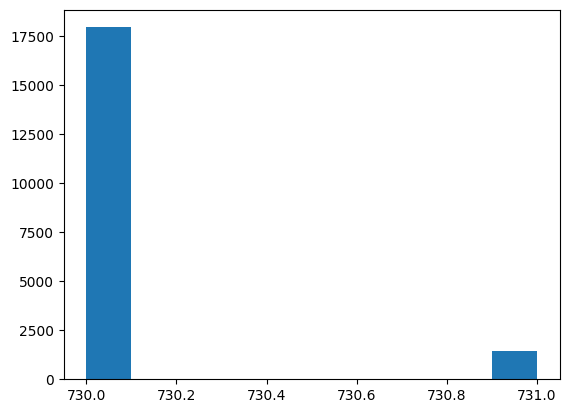

In [44]:
plt.hist(preds)